# CV quantum teleportation

Compare the optical teleportation channel with its analytical added noise.

The Braunstein–Kimble protocol uses an entangled two-mode resource and two quadrature measurements. Its unconditional covariance adds 2 exp(-2r) I. A selected trajectory differs from this average channel.

Unconditional output mean: [0.6 0.2]
Added noise: [[ 0.403793 -0.      ]
 [-0.        0.403793]]
Conditional outcomes: {0: 0.4259093188015401, 1: 0.5409740781537619}


<Axes: title={'center': 'MBQC connectivity · squares: inputs · diamonds: outputs\ntriangles: PNR · dashed arrows: classical control'}>

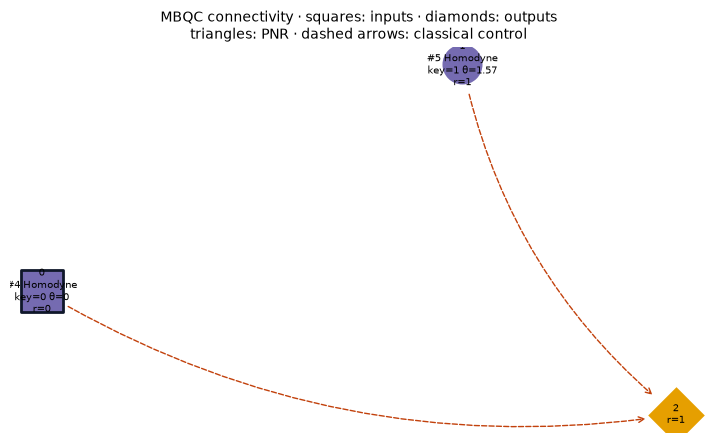

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import photographiq as pg
pattern = pg.protocols.teleportation(squeezing=0.8)
channel = pg.gaussian_channel(pattern)
initial = pg.GaussianInput.coherent(0.3+0.1j).state(0)
output = channel.apply(initial)
print("Unconditional output mean:", np.round(output.mean, 6))
print("Added noise:", np.round(channel.noise, 6))
np.testing.assert_allclose(channel.noise, 2*np.exp(-1.6)*np.eye(2), atol=1e-12)
print("Conditional outcomes:", pg.simulate(pattern, inputs={0:pg.GaussianInput.coherent(0.3+0.1j)},seed=7).outcomes)
pattern.draw()

## Interpretation

The channel preserves the coherent displacement and adds noise. The sampled outcomes are real measurement readings, not probabilities or target amplitudes.

## Exercise

Sweep r and compute overlap with a pure coherent target relabelled to the output. Compare channel moments with a large shot ensemble.